# **Model Training (Binary Classification)** #

- Load processed dataset
- Import models from src/
- Train models
- Evaluate
- Save results 
- Select Best model
- Save Best model

# Section 1 - Load Dataset 

In [1]:
import joblib

X_train_bal, X_test, y_train_bal, y_test = joblib.load(
    "../data/processed/binary_dataset.pkl"
)

print(X_train_bal.shape, X_test.shape)

(10952, 10) (3000, 10)


# Section 2 — Import From src/

In [2]:
import sys
import os
sys.path.append(os.path.abspath(".."))

from src.models import (
    get_logistic,
    get_decision_tree,
    get_random_forest,
    get_svm
)

from src.evaluation import evaluate_binary

# Section 3 - Train All Models

In [3]:
models = {
    "Logistic Regression": get_logistic(),
    "Decision Tree": get_decision_tree(),
    "Random Forest": get_random_forest(),
    "SVM": get_svm()
}

results = {}

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    metrics = evaluate_binary(y_test, y_pred, y_prob)
    results[name] = metrics

results

{'Logistic Regression': {'accuracy': 0.8513333333333334,
  'precision': 0.16666666666666666,
  'recall': 0.8431372549019608,
  'f1': 0.2783171521035599,
  'roc_auc': 0.916081408408774},
 'Decision Tree': {'accuracy': 0.9383333333333334,
  'precision': 0.32489451476793246,
  'recall': 0.7549019607843137,
  'f1': 0.45427728613569324,
  'roc_auc': 0.8498457353956075},
 'Random Forest': {'accuracy': 0.957,
  'precision': 0.425414364640884,
  'recall': 0.7549019607843137,
  'f1': 0.5441696113074205,
  'roc_auc': 0.9590369964410885},
 'SVM': {'accuracy': 0.8096666666666666,
  'precision': 0.11620294599018004,
  'recall': 0.696078431372549,
  'f1': 0.19915848527349228,
  'roc_auc': 0.8246931622890702}}

# Logistic Regression

In [4]:
log_model = get_logistic()
log_model.fit(X_train_bal, y_train_bal)

log_pred = log_model.predict(X_test)
log_prob = log_model.predict_proba(X_test)[:, 1]

log_metrics = evaluate_binary(y_test, log_pred, log_prob)
log_metrics

{'accuracy': 0.8513333333333334,
 'precision': 0.16666666666666666,
 'recall': 0.8431372549019608,
 'f1': 0.2783171521035599,
 'roc_auc': 0.916081408408774}

# Decision Tree

In [5]:
dt_model = get_decision_tree()
dt_model.fit(X_train_bal, y_train_bal)

dt_pred = dt_model.predict(X_test)
dt_prob = dt_model.predict_proba(X_test)[:, 1]

dt_metrics = evaluate_binary(y_test, dt_pred, dt_prob)
dt_metrics

{'accuracy': 0.9383333333333334,
 'precision': 0.32489451476793246,
 'recall': 0.7549019607843137,
 'f1': 0.45427728613569324,
 'roc_auc': 0.8498457353956075}

# Random Forest

In [6]:
rf_model = get_random_forest()
rf_model.fit(X_train_bal, y_train_bal)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

rf_metrics = evaluate_binary(y_test, rf_pred, rf_prob)
rf_metrics

{'accuracy': 0.957,
 'precision': 0.425414364640884,
 'recall': 0.7549019607843137,
 'f1': 0.5441696113074205,
 'roc_auc': 0.9590369964410885}

# SVM

In [7]:
svm_model = get_svm()
svm_model.fit(X_train_bal, y_train_bal)

svm_pred = svm_model.predict(X_test)
svm_prob = svm_model.predict_proba(X_test)[:, 1]

svm_metrics = evaluate_binary(y_test, svm_pred, svm_prob)
svm_metrics

{'accuracy': 0.8096666666666666,
 'precision': 0.11620294599018004,
 'recall': 0.696078431372549,
 'f1': 0.19915848527349228,
 'roc_auc': 0.8247303752418842}

# Comparison Table

In [8]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Logistic Regression": log_metrics,
    "Decision Tree": dt_metrics,
    "Random Forest": rf_metrics,
    "SVM": svm_metrics
}).T

comparison_df

,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.851333,0.166667,0.843137,0.278317,0.916081
Decision Tree,0.938333,0.324895,0.754902,0.454277,0.849846
Random Forest,0.957000,0.425414,0.754902,0.544170,0.959037
SVM,0.809667,0.116203,0.696078,0.199158,0.824730


In [9]:
comparison_df = comparison_df.round(3)
comparison_df

,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.851,0.167,0.843,0.278,0.916
Decision Tree,0.938,0.325,0.755,0.454,0.850
Random Forest,0.957,0.425,0.755,0.544,0.959
SVM,0.810,0.116,0.696,0.199,0.825


# Bar Graph Comparison (F1 + Recall + Precision)

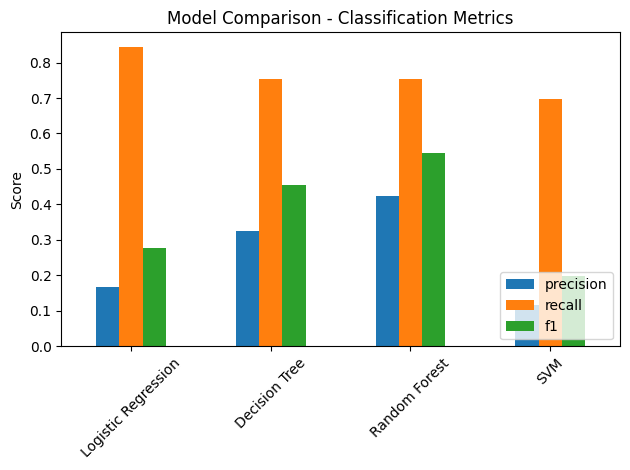

In [10]:
import matplotlib.pyplot as plt

comparison_df[["precision", "recall", "f1"]].plot(kind="bar")
plt.title("Model Comparison - Classification Metrics")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# ROC Curve Comparison

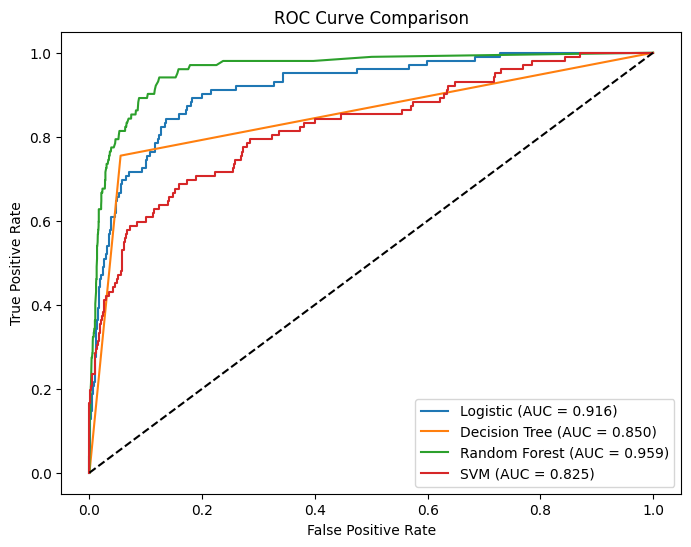

In [11]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

models_probs = {
    "Logistic": log_prob,
    "Decision Tree": dt_prob,
    "Random Forest": rf_prob,
    "SVM": svm_prob
}

for name, probs in models_probs.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# Best Model

In [12]:
best_model = comparison_df["f1"].idxmax()
print("Best Model based on F1-score:", best_model)

Best Model based on F1-score: Random Forest


# Save Best Model

In [15]:
os.makedirs("artifacts", exist_ok=True)

joblib.dump(best_model, "../artifacts/best_model.pkl")

print("Model saved successfully.")

Model saved successfully.
